In [4]:
import pandas as pd 
import numpy as np 
from sklearn.datasets import make_classification 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression

In [5]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [6]:
X.shape

(100, 2)

In [7]:
y.shape

(100,)

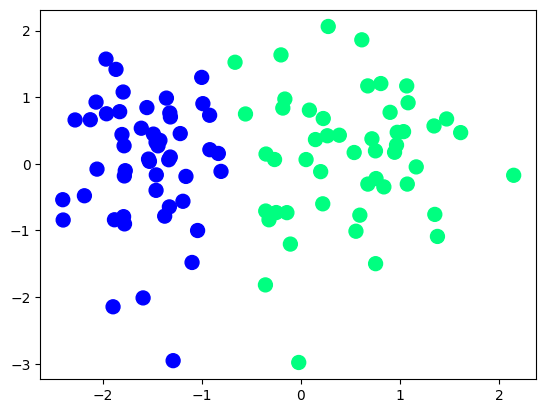

In [8]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [9]:
X.shape

(100, 2)

In [10]:
def step(z):
    return 1 if z>0 else 0

In [11]:
class perceptron():
    def __init__(self,learning_rate=0.1,epochs=200):
        self.learning_rate=learning_rate
        self.epochs=epochs
        self.weights = None
    def fit(self,X,y):
        X=np.insert(X,0,1,axis=1)
        self.weights= np.ones(X.shape[1])
        for i in range(self.epochs):
            j=np.random.randint(0,X.shape[0])
            y_hat=step(np.dot(X[j],self.weights))
            self.weights=self.weights+self.learning_rate* (y[j]-y_hat)*X[j]
        return self.weights[0] , self.weights[1:]
    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        return np.array([step(np.dot(x, self.weights)) for x in X])

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = perceptron(learning_rate=0.1, epochs=1000)
bias, weights = clf.fit(X_train, y_train)
print(f"Bias (w0)  : {bias:.4f}")
print(f"Weights    : {weights}")

Bias (w0)  : 0.9000
Weights    : [1.41262171 0.16062727]


In [13]:
from sklearn.metrics import accuracy_score
# Custom Perceptron
y_pred_custom = clf.predict(X_test)
acc_custom = accuracy_score(y_test, y_pred_custom)
# sklearn LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_sklearn = lr.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Custom Perceptron Accuracy : {acc_custom * 100:.2f}%")
print(f"sklearn LogisticRegression : {acc_sklearn * 100:.2f}%")

Custom Perceptron Accuracy : 100.00%
sklearn LogisticRegression : 100.00%


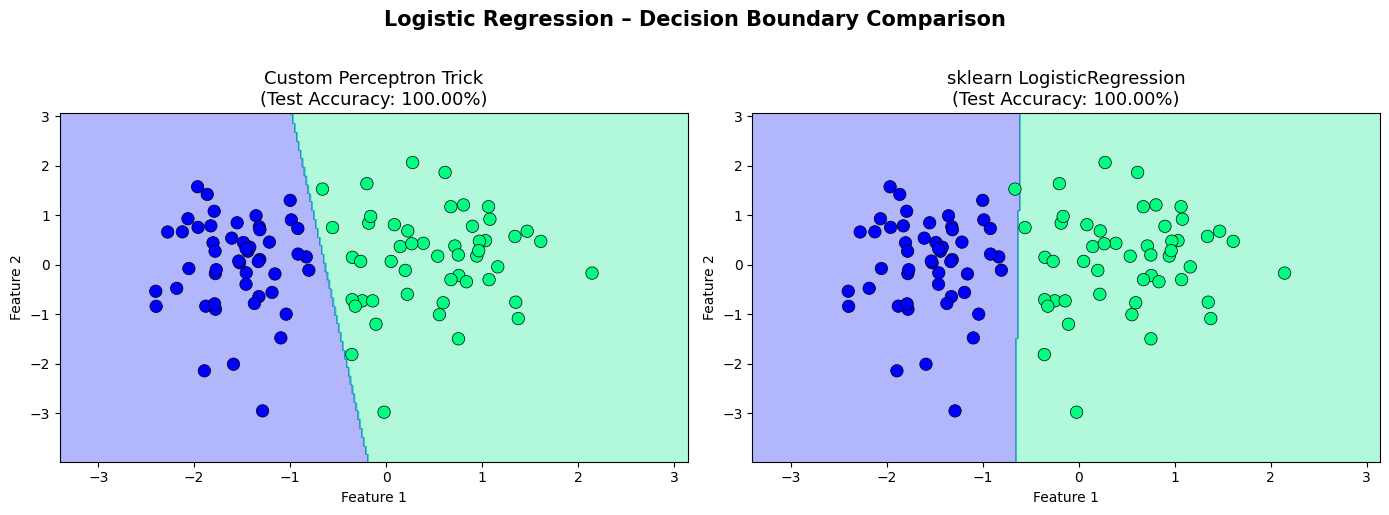

In [14]:
def plot_decision_boundary(clf_custom, clf_sklearn, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_custom  = clf_custom.predict(grid).reshape(xx.shape)
    Z_sklearn = clf_sklearn.predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Custom Perceptron
    axes[0].contourf(xx, yy, Z_custom, alpha=0.3, cmap='winter')
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='winter',
                    s=80, edgecolors='k', linewidths=0.5)
    axes[0].set_title(
        f'Custom Perceptron Trick\n'
        f'(Test Accuracy: {accuracy_score(y_test, clf_custom.predict(X_test))*100:.2f}%)',
        fontsize=13
    )
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')

    # sklearn LogisticRegression
    axes[1].contourf(xx, yy, Z_sklearn, alpha=0.3, cmap='winter')
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='winter',
                    s=80, edgecolors='k', linewidths=0.5)
    axes[1].set_title(
        f'sklearn LogisticRegression\n'
        f'(Test Accuracy: {accuracy_score(y_test, clf_sklearn.predict(X_test))*100:.2f}%)',
        fontsize=13
    )
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')

    plt.suptitle('Logistic Regression – Decision Boundary Comparison',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_decision_boundary(clf, lr, X, y)
